# Structure Prediction and Target Comparison for Alanine-Racemase Designs

This notebook evaluates ProteinMPNN sequences designed for the 382-residue modeled chain A of PLP-dependent alanine racemase (PDB 1SFT).

1. Read candidate sequences from the alanine-racemase ProteinMPNN FASTA output.
2. Select the designed sequence with the lowest ProteinMPNN score.
3. Predict its single-chain structure with the local ESMFold model.
4. Superimpose the prediction on the experimental chain-A backbone and calculate Cα RMSD.
5. Inspect per-residue deviations and an overlay that also shows the target PLP cofactor.

Default design input:

```text
/data/home/xiongwen2/proteinmpnn/Lecture/outputs/example_1_alanine_racemase_T0.1/seqs/target.fa
```

Run Example 1 in `1.ProteinMPNN_design.ipynb` after replacing the target, so that the FASTA contains the new 382-residue designs rather than results from the previous target.


## Part 1: Environment and absolute paths

If the dependencies below are not installed in the current environment, run the installation cell once. Restart the Jupyter kernel if prompted.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import biotite.structure as struc
import biotite.structure.io.pdb as pdbio
import py3Dmol

from transformers import AutoTokenizer, EsmForProteinFolding
from transformers.models.esm.openfold_utils.feats import atom14_to_atom37
from transformers.models.esm.openfold_utils.protein import Protein as OFProtein
from transformers.models.esm.openfold_utils.protein import to_pdb

os.environ["CUDA_VISIBLE_DEVICES"] = "0" #Number of your group

TARGET_PDB = "Your path/target.pdb"
DESIGN_FASTA = "Your path/target.fa"
ESMFOLD_MODEL_PATH = "/data/home/xiongwen2/software/esmfold_v1"
PREDICTION_DIR = "Your path/predict_structure"

required_paths = [TARGET_PDB, DESIGN_FASTA, ESMFOLD_MODEL_PATH]
missing_paths = [path for path in required_paths if not os.path.exists(path)]
if missing_paths:
    raise FileNotFoundError("The following paths do not exist:\n" + "\n".join(missing_paths))

os.makedirs(PREDICTION_DIR, exist_ok=True)

print(f"Target: PLP-dependent alanine racemase (PDB 1SFT, chain A)")
print(f"Target backbone: {TARGET_PDB}")
print(f"Design sequences: {DESIGN_FASTA}")
print(f"ESMFold: {ESMFOLD_MODEL_PATH}")
print(f"Output directory: {PREDICTION_DIR}")


Target: PLP-dependent alanine racemase (PDB 1SFT, chain A)
Target backbone: /data/home/student1/tt1/data/target.pdb
Design sequences: /data/home/student1/tt1/outputs/example_1_alanine_racemase_T0.1/seqs/target.fa
ESMFold: /data/home/xiongwen2/software/esmfold_v1
Output directory: /data/home/student1/tt1/predict_structure


## Part 2: Select an alanine-racemase design for prediction

The first record in a ProteinMPNN output FASTA file is usually the native sequence, followed by designed sequences. The code below reads only design records whose headers begin with `T=` and selects the sequence with the lowest score. A length check confirms that the selected sequence matches the 382 modeled target residues before ESMFold is run.


In [2]:
def load_design_fasta(fasta_path):
    with open(fasta_path, "r", encoding="utf-8") as handle:
        fasta_lines = [line.strip() for line in handle if line.strip()]

    records = []
    for header, sequence in zip(fasta_lines[0::2], fasta_lines[1::2]):
        header = header.removeprefix(">")
        if not header.startswith("T="):
            continue

        fields = dict(item.split("=", 1) for item in header.split(", "))
        records.append(
            {
                "temperature": float(fields["T"]),
                "sample": int(fields["sample"]),
                "score": float(fields["score"]),
                "global_score": float(fields["global_score"]),
                "seq_recovery": float(fields["seq_recovery"]),
                "sequence": sequence.replace("/", ""),
            }
        )

    results = pd.DataFrame(records)
    if results.empty:
        raise ValueError(f"No ProteinMPNN design records were found in: {fasta_path}")
    return results


target_pdb_file = pdbio.PDBFile.read(TARGET_PDB)
target_structure = target_pdb_file.get_structure(model=1, altloc="occupancy")
target_protein = target_structure[struc.filter_amino_acids(target_structure)]
target_ca_count = int(np.sum(target_protein.atom_name == "CA"))

design_results = load_design_fasta(DESIGN_FASTA)
best_design = design_results.sort_values("score").iloc[0]
sequence_to_fold = best_design["sequence"]

if len(sequence_to_fold) != target_ca_count:
    raise ValueError(
        f"Selected sequence length ({len(sequence_to_fold)}) does not match "
        f"the target modeled-residue count ({target_ca_count}). "
        "Rerun ProteinMPNN with the alanine-racemase target."
    )

display(best_design.to_frame(name="value"))
print(f"Selected sequence length: {len(sequence_to_fold)}")
print(f"Target modeled-residue count: {target_ca_count}")


,value
temperature,0.1
sample,8
score,0.7556
global_score,0.7556
seq_recovery,0.5445
sequence,GSFDIPLYAEVDLDAVYYNVSKMRELLPPDTKIMIVVGSDALGLGA...


Selected sequence length: 382
Target modeled-residue count: 382


## Part 3: Predict the structure with ESMFold

The function accepts one single-chain sequence at a time. The local ESMFold weights are loaded on the first call and the cached model is reused for subsequent predictions.


In [3]:
ESMFOLD_CHUNK_SIZE = 64

_esmfold_tokenizer = None
_esmfold_model = None
_esmfold_device = None
_esmfold_loaded_path = None


def _load_esmfold(model_path=ESMFOLD_MODEL_PATH, chunk_size=ESMFOLD_CHUNK_SIZE):
    global _esmfold_tokenizer, _esmfold_model, _esmfold_device, _esmfold_loaded_path

    model_path = os.path.abspath(os.path.expanduser(model_path))
    if not os.path.isdir(model_path):
        raise FileNotFoundError(f"ESMFold model directory not found: {model_path}")

    if _esmfold_model is not None and _esmfold_loaded_path == model_path:
        _esmfold_model.trunk.set_chunk_size(chunk_size)
        return _esmfold_tokenizer, _esmfold_model, _esmfold_device

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cpu":
        print("Warning: CUDA is unavailable. ESMFold is very slow and memory intensive on a CPU.")

    tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
    model = EsmForProteinFolding.from_pretrained(
        model_path,
        low_cpu_mem_usage=True,
        local_files_only=True,
    )
    model = model.eval().to(device)
    model.trunk.set_chunk_size(chunk_size)

    if device.type == "cuda":
        torch.backends.cuda.matmul.allow_tf32 = True

    _esmfold_tokenizer = tokenizer
    _esmfold_model = model
    _esmfold_device = device
    _esmfold_loaded_path = model_path
    return tokenizer, model, device


def _single_output_to_pdb(outputs):
    if outputs["aatype"].shape[0] != 1:
        raise ValueError("Only one ESMFold prediction is accepted here")

    atom37_positions = atom14_to_atom37(outputs["positions"][-1], outputs)
    cpu_outputs = {
        key: value.detach().cpu().numpy()
        for key, value in outputs.items()
        if torch.is_tensor(value)
    }

    chain_index = cpu_outputs.get("chain_index")
    prediction = OFProtein(
        aatype=cpu_outputs["aatype"][0],
        atom_positions=atom37_positions[0].detach().cpu().numpy(),
        atom_mask=cpu_outputs["atom37_atom_exists"][0],
        residue_index=cpu_outputs["residue_index"][0] + 1,
        b_factors=cpu_outputs["plddt"][0],
        chain_index=chain_index[0] if chain_index is not None else None,
    )
    return to_pdb(prediction)


def predict_one_structure(
    sequence,
    output_path,
    model_path=ESMFOLD_MODEL_PATH,
    chunk_size=ESMFOLD_CHUNK_SIZE,
    max_length=2048,
):
    if not isinstance(sequence, str):
        raise TypeError("sequence must be a single amino-acid sequence string")

    sequence = "".join(sequence.split()).upper()
    if not sequence:
        raise ValueError("sequence must not be empty")
    if "/" in sequence or ":" in sequence:
        raise ValueError("This function predicts one chain at a time; remove chain separators")
    if len(sequence) > max_length:
        raise ValueError(f"Sequence length {len(sequence)} exceeds the limit of {max_length}")

    allowed_amino_acids = set("ACDEFGHIKLMNPQRSTVWYX")
    invalid_amino_acids = sorted(set(sequence) - allowed_amino_acids)
    if invalid_amino_acids:
        raise ValueError(f"Unsupported amino-acid symbols: {invalid_amino_acids}")

    tokenizer, model, device = _load_esmfold(model_path, chunk_size)
    tokenized_input = tokenizer(
        [sequence],
        return_tensors="pt",
        add_special_tokens=False,
    )["input_ids"].to(device)

    with torch.inference_mode():
        outputs = model(tokenized_input)

    mean_plddt = float(outputs["plddt"][0, :, 1].mean().detach().cpu())
    ptm = float(outputs["ptm"].detach().cpu().reshape(-1)[0].item()) if "ptm" in outputs else np.nan
    pdb_text = _single_output_to_pdb(outputs)

    output_path = os.path.abspath(output_path)
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, "w", encoding="utf-8") as handle:
        handle.write(pdb_text)

    del tokenized_input, outputs
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "pdb_path": output_path,
        "sequence_length": len(sequence),
        "mean_plddt": mean_plddt,
        "ptm": ptm,
        "device": str(device),
    }


In [4]:
prediction = predict_one_structure(
    sequence=sequence_to_fold,
    output_path=os.path.join(PREDICTION_DIR, "best_design.pdb"),
)

prediction


Some weights of EsmForProteinFolding were not initialized from the model checkpoint at /data/home/xiongwen2/software/esmfold_v1 and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'pdb_path': '/data/home/student1/tt1/predict_structure/best_design.pdb',
 'sequence_length': 382,
 'mean_plddt': 0.9154656529426575,
 'ptm': 0.9133843779563904,
 'device': 'cuda'}

### View the ESMFold prediction

The generated PDB stores pLDDT values in the B-factor column. The result dictionary also reports mean pLDDT and pTM.


In [5]:
with open(prediction["pdb_path"], "r", encoding="utf-8") as handle:
    predicted_pdb_text = handle.read()

predicted_view = py3Dmol.view(width=700, height=500)
predicted_view.addModel(predicted_pdb_text, "pdb")
predicted_view.setStyle({"cartoon": {"color": "spectrum"}})
predicted_view.setBackgroundColor("white")
predicted_view.zoomTo()
predicted_view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Part 4: Compare the prediction with the alanine-racemase backbone

The 382 corresponding Cα atoms are superimposed with the Kabsch algorithm. The code then calculates overall Cα RMSD, mean deviation, maximum deviation, and per-residue deviations.

The PLP cofactor is excluded from the RMSD because ESMFold predicts only the protein chain. It is retained in the target PDB and displayed in the final overlay to show the location of the catalytic pocket.


In [6]:
def _load_protein_atoms(pdb_path):
    pdb_file = pdbio.PDBFile.read(pdb_path)
    atoms = pdb_file.get_structure(model=1, altloc="occupancy")
    return atoms[struc.filter_amino_acids(atoms)]


def _kabsch_superimpose(reference_coordinates, mobile_coordinates):
    reference_coordinates = np.asarray(reference_coordinates, dtype=float)
    mobile_coordinates = np.asarray(mobile_coordinates, dtype=float)

    reference_center = reference_coordinates.mean(axis=0)
    mobile_center = mobile_coordinates.mean(axis=0)
    reference_centered = reference_coordinates - reference_center
    mobile_centered = mobile_coordinates - mobile_center

    covariance = mobile_centered.T @ reference_centered
    left_vectors, _, right_vectors_transposed = np.linalg.svd(covariance)

    if np.linalg.det(left_vectors @ right_vectors_transposed) < 0:
        left_vectors[:, -1] *= -1

    rotation = left_vectors @ right_vectors_transposed
    aligned_coordinates = mobile_centered @ rotation + reference_center
    return aligned_coordinates, rotation, reference_center, mobile_center


def compare_backbones(target_path, predicted_path, aligned_output_path):
    target_atoms = _load_protein_atoms(target_path)
    predicted_atoms = _load_protein_atoms(predicted_path)

    target_ca = target_atoms[target_atoms.atom_name == "CA"]
    predicted_ca = predicted_atoms[predicted_atoms.atom_name == "CA"]

    if len(target_ca) != len(predicted_ca):
        raise ValueError(
            "The target and predicted structures have different numbers of Cα atoms: "
            f"{len(target_ca)} versus {len(predicted_ca)}. "
            "Perform a sequence or structural alignment before defining residue correspondences."
        )
    if len(target_ca) < 3:
        raise ValueError("At least three pairs of Cα atoms are required for structural superposition")

    aligned_ca, rotation, reference_center, mobile_center = _kabsch_superimpose(
        target_ca.coord,
        predicted_ca.coord,
    )

    ca_deviation = np.linalg.norm(target_ca.coord - aligned_ca, axis=1)
    ca_rmsd = float(np.sqrt(np.mean(ca_deviation ** 2)))

    aligned_prediction = predicted_atoms.copy()
    aligned_prediction.coord = (
        (predicted_atoms.coord - mobile_center) @ rotation + reference_center
    )

    aligned_output_path = os.path.abspath(aligned_output_path)
    os.makedirs(os.path.dirname(aligned_output_path), exist_ok=True)
    aligned_pdb_file = pdbio.PDBFile()
    aligned_pdb_file.set_structure(aligned_prediction)
    aligned_pdb_file.write(aligned_output_path)

    comparison_summary = {
        "ca_atom_count": len(target_ca),
        "ca_rmsd_angstrom": ca_rmsd,
        "mean_ca_deviation_angstrom": float(ca_deviation.mean()),
        "max_ca_deviation_angstrom": float(ca_deviation.max()),
        "aligned_pdb_path": aligned_output_path,
    }

    residue_deviation = pd.DataFrame(
        {
            "chain_position": np.arange(1, len(target_ca) + 1),
            "target_residue_id": target_ca.res_id,
            "ca_deviation_angstrom": ca_deviation,
        }
    )
    return comparison_summary, residue_deviation


In [7]:
comparison, residue_deviation = compare_backbones(
    target_path=TARGET_PDB,
    predicted_path=prediction["pdb_path"],
    aligned_output_path=os.path.join(PREDICTION_DIR, "best_design_aligned.pdb"),
)

evaluation_summary = pd.DataFrame(
    [
        {
            "mean_plddt": prediction["mean_plddt"],
            "ptm": prediction["ptm"],
            "ca_rmsd_angstrom": comparison["ca_rmsd_angstrom"],
            "mean_ca_deviation_angstrom": comparison["mean_ca_deviation_angstrom"],
            "max_ca_deviation_angstrom": comparison["max_ca_deviation_angstrom"],
        }
    ]
)

display(
    evaluation_summary.rename(
        columns={
            "mean_plddt": "Mean pLDDT",
            "ptm": "pTM",
            "ca_rmsd_angstrom": "Cα RMSD（Å）",
            "mean_ca_deviation_angstrom": "Mean Cα deviation (Å)",
            "max_ca_deviation_angstrom": "Maximum Cα deviation (Å)",
        }
    ).round(3)
)

print(f"Aligned predicted structure: {comparison['aligned_pdb_path']}")


,Mean pLDDT,pTM,Cα RMSD（Å）,Mean Cα deviation (Å),Maximum Cα deviation (Å)
0,0.915,0.913,1.205,0.821,12.657


Aligned predicted structure: /data/home/student1/tt1/predict_structure/best_design_aligned.pdb


### Inspect per-residue structural deviations

High peaks mark local regions that deviate from the target backbone. A low global RMSD does not imply that every loop or terminal region is identical.


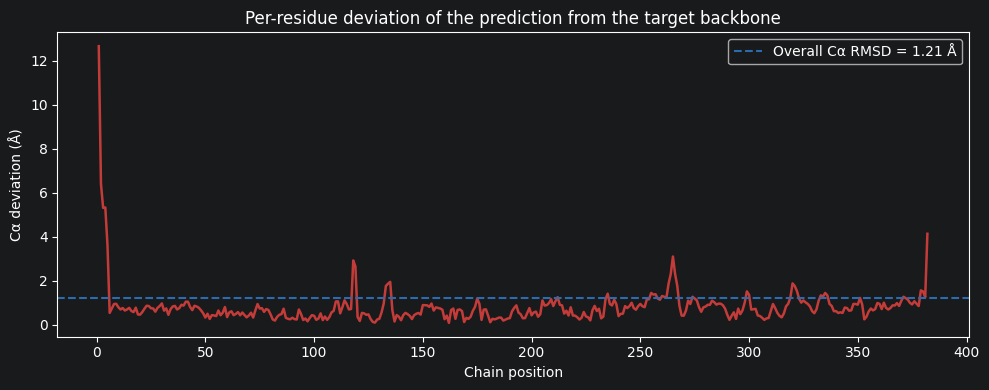

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    residue_deviation["chain_position"],
    residue_deviation["ca_deviation_angstrom"],
    color="#c43c39",
    linewidth=1.8,
)
ax.axhline(
    comparison["ca_rmsd_angstrom"],
    color="#2b6cb0",
    linestyle="--",
    label=f"Overall Cα RMSD = {comparison['ca_rmsd_angstrom']:.2f} Å",
)
ax.set_xlabel("Chain position")
ax.set_ylabel("Cα deviation (Å)")
ax.set_title("Per-residue deviation of the prediction from the target backbone")
ax.legend()
plt.tight_layout()
plt.show()


### Overlay the prediction, target backbone, and PLP

- **Blue**: experimental alanine-racemase chain-A backbone.
- **Green sticks**: PLP cofactor from the target structure.
- **Red**: ESMFold prediction for the designed sequence after optimal superposition.


In [9]:
with open(TARGET_PDB, "r", encoding="utf-8") as handle:
    target_pdb_text = handle.read()
with open(comparison["aligned_pdb_path"], "r", encoding="utf-8") as handle:
    aligned_prediction_text = handle.read()

overlay_view = py3Dmol.view(width=800, height=550)
overlay_view.addModel(target_pdb_text, "pdb")
overlay_view.setStyle(
    {"model": 0, "hetflag": False},
    {"cartoon": {"color": "#2b6cb0", "opacity": 0.85}},
)
overlay_view.setStyle(
    {"model": 0, "resn": "PLP"},
    {"stick": {"colorscheme": "greenCarbon", "radius": 0.22}},
)
overlay_view.addModel(aligned_prediction_text, "pdb")
overlay_view.setStyle(
    {"model": 1},
    {"cartoon": {"color": "#c43c39", "opacity": 0.70}},
)
overlay_view.setBackgroundColor("white")
overlay_view.zoomTo()
overlay_view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Interpreting the results

An ideal candidate generally combines high pLDDT, high pTM, and low Cα RMSD. Do not rely on a single metric: high pLDDT indicates confidence in the predicted structure, but that structure may still differ from the target backbone. RMSD directly measures the geometric difference between the prediction and the target.

To evaluate another candidate, change `DESIGN_FASTA` or manually select a different row from `design_results` in Part 2, then rerun the structure-prediction and comparison cells.
